In [512]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap
import trimap
import pacmap

RANDOM_STATE=318

In [513]:
file_path = 'soybean-large.data'
column_names = ['class'] + [f'attr_{i}' for i in range(35)]
data = pd.read_csv(file_path, header=None, names=column_names, na_values='?')

class_counts = data['class'].value_counts()
rare_classes = class_counts[class_counts < 2].index

if not rare_classes.empty:
    print(f"Обнаружены слишком редкие классы: {list(rare_classes)}")
    print(f"Удаление {len(rare_classes)} объекта(ов) для корректной стратификации...")
    data = data[~data['class'].isin(rare_classes)].reset_index(drop=True)

Обнаружены слишком редкие классы: ['2-4-d-injury']
Удаление 1 объекта(ов) для корректной стратификации...


In [514]:
X = data.drop('class', axis=1)
y = data['class']

imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [515]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_encoded, test_size=0.3, random_state=RANDOM_STATE, stratify=y_encoded
)

In [516]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [517]:
results = {}

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred, average='weighted')
    results[model_name] = score

In [518]:
svm = SVC(kernel='rbf', random_state=RANDOM_STATE)
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

In [519]:
train_and_evaluate(svm, X_train_scaled, y_train, X_test_scaled, y_test, 'SVM (Baseline)')
train_and_evaluate(knn, X_train_scaled, y_train, X_test_scaled, y_test, 'k-NN (Baseline)')
train_and_evaluate(rf, X_train_scaled, y_train, X_test_scaled, y_test, 'RF (Baseline)')

In [520]:
try:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    bsmote1 = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1', k_neighbors=1, m_neighbors=2)
    X_train_bsmote1, y_train_bsmote1 = bsmote1.fit_resample(X_train_scaled, y_train)

    bsmote2 = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-2', k_neighbors=1, m_neighbors=2)
    X_train_bsmote2, y_train_bsmote2 = bsmote2.fit_resample(X_train_scaled, y_train)

    balanced_datasets = {
        "SMOTE": (X_train_smote, y_train_smote),
        "Borderline-1": (X_train_bsmote1, y_train_bsmote1),
        "Borderline-2": (X_train_bsmote2, y_train_bsmote2)
    }
except ValueError as e:
    print(f"Ошибка при балансировке: {e}. Пропускаем...")
    balanced_datasets = {}

In [521]:
if balanced_datasets:
    for method_name, (X_bal, y_bal) in balanced_datasets.items():
        svm_bal = SVC(kernel='rbf', random_state=RANDOM_STATE)
        knn_bal = KNeighborsClassifier(n_neighbors=5)
        rf_bal = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

        train_and_evaluate(svm_bal, X_bal, y_bal, X_test_scaled, y_test, f'SVM ({method_name})')
        train_and_evaluate(knn_bal, X_bal, y_bal, X_test_scaled, y_test, f'k-NN ({method_name})')
        train_and_evaluate(rf_bal, X_bal, y_bal, X_test_scaled, y_test, f'RF ({method_name})')
else:
    print("\nОбучение на сбалансированных данных пропущено из-за ошибки.")

In [522]:
# Визуализация результатов F1-score (как в pr4.ipynb)
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Weighted F1-Score'])
results_df.sort_values(by='Weighted F1-Score', ascending=False, inplace=True)
print("\n===== СРАВНЕНИЕ F1-SCORE =====")
print(results_df)


===== СРАВНЕНИЕ F1-SCORE =====
                     Weighted F1-Score
RF (Borderline-1)             0.944950
RF (Borderline-2)             0.921677
RF (Baseline)                 0.911491
RF (SMOTE)                    0.909384
SVM (Borderline-2)            0.901277
SVM (Borderline-1)            0.901277
SVM (Baseline)                0.900402
SVM (SMOTE)                   0.890408
k-NN (Borderline-2)           0.869103
k-NN (Borderline-1)           0.869103
k-NN (SMOTE)                  0.858905
k-NN (Baseline)               0.801783


In [523]:
def plot_embeddings_comparison(X_data, y_true, model, label_encoder, title_prefix):
    y_pred = model.predict(X_data)
    y_true_labels = label_encoder.inverse_transform(y_true)
    y_pred_labels = label_encoder.inverse_transform(y_pred)

    class_names = list(label_encoder.classes_)

    tsne_params = [
        {'perplexity': 30, 'max_iter': 1000, 'random_state': RANDOM_STATE},
        {'perplexity': 5, 'max_iter': 1000, 'random_state': RANDOM_STATE}
    ]
    umap_params = [
        {'n_neighbors': 15, 'min_dist': 0.1, 'random_state': RANDOM_STATE},
        {'n_neighbors': 5, 'min_dist': 0.1, 'random_state': RANDOM_STATE}
    ]
    trimap_params = [
        {'n_dims': 2, 'n_random': RANDOM_STATE},
        {'n_dims': 2, 'n_inliers': 5, 'n_random': RANDOM_STATE}
    ]
    pacmap_params = [
        {'n_components': 2, 'n_neighbors': 10, 'random_state': RANDOM_STATE},
        {'n_components': 2, 'n_neighbors': 5, 'random_state': RANDOM_STATE}
    ]
    embedding_methods = {
        "t-SNE": (TSNE, tsne_params),
        "UMAP": (umap.UMAP, umap_params),
        "TriMAP": (trimap.TRIMAP, trimap_params),
        "PaCMAP": (pacmap.PaCMAP, pacmap_params)
    }
    # -----------------------------------------------------------------

    plot_df = pd.DataFrame()
    plot_df['Истинные метки'] = y_true_labels
    plot_df['Предсказанные метки'] = y_pred_labels

    sns.set(style='white')

    for name, (Algo, param_list) in embedding_methods.items():
        for i, params in enumerate(param_list, 1):
            print(f"Выполняется {name} с параметрами: {params}...")
            viz_params = params.copy()
            if name == "TriMAP":
                viz_params.pop('n_iter', None)
                viz_params.pop('max_iter', None)
            elif name == "t-SNE":
                viz_params.pop('n_iter', None)

            emb = Algo(**viz_params).fit_transform(X_data)

            plot_df['x'] = emb[:, 0]
            plot_df['y'] = emb[:, 1]

            fig, ax = plt.subplots(1, 2, figsize=(16, 7))
            fig.suptitle(f"{title_prefix} - {name} (вариант {i}: {params})", fontsize=16)

            sns.scatterplot(
                data=plot_df, x='x', y='y', hue='Истинные метки',
                ax=ax[0], palette='tab20', s=15,
                hue_order=class_names,
                legend=True,
                alpha=0.8
            )
            ax[0].set_title("Истинные метки")

            sns.scatterplot(
                data=plot_df, x='x', y='y', hue='Предсказанные метки',
                ax=ax[1], palette='tab20', s=15,
                hue_order=class_names,
                legend=False,
                alpha=0.8
            )
            ax[1].set_title("Предсказанные метки")

            handles, labels = ax[0].get_legend_handles_labels()

            ax[0].get_legend().remove()

            fig.legend(handles, labels,
                       loc='center left',
                       bbox_to_anchor=(0.86, 0.5),
                       fontsize='small',
                       title="Классы")

            plt.tight_layout(rect=[0, 0, 0.85, 0.95])
            plt.show()

Выполняется t-SNE с параметрами: {'perplexity': 30, 'max_iter': 1000, 'random_state': 318}...


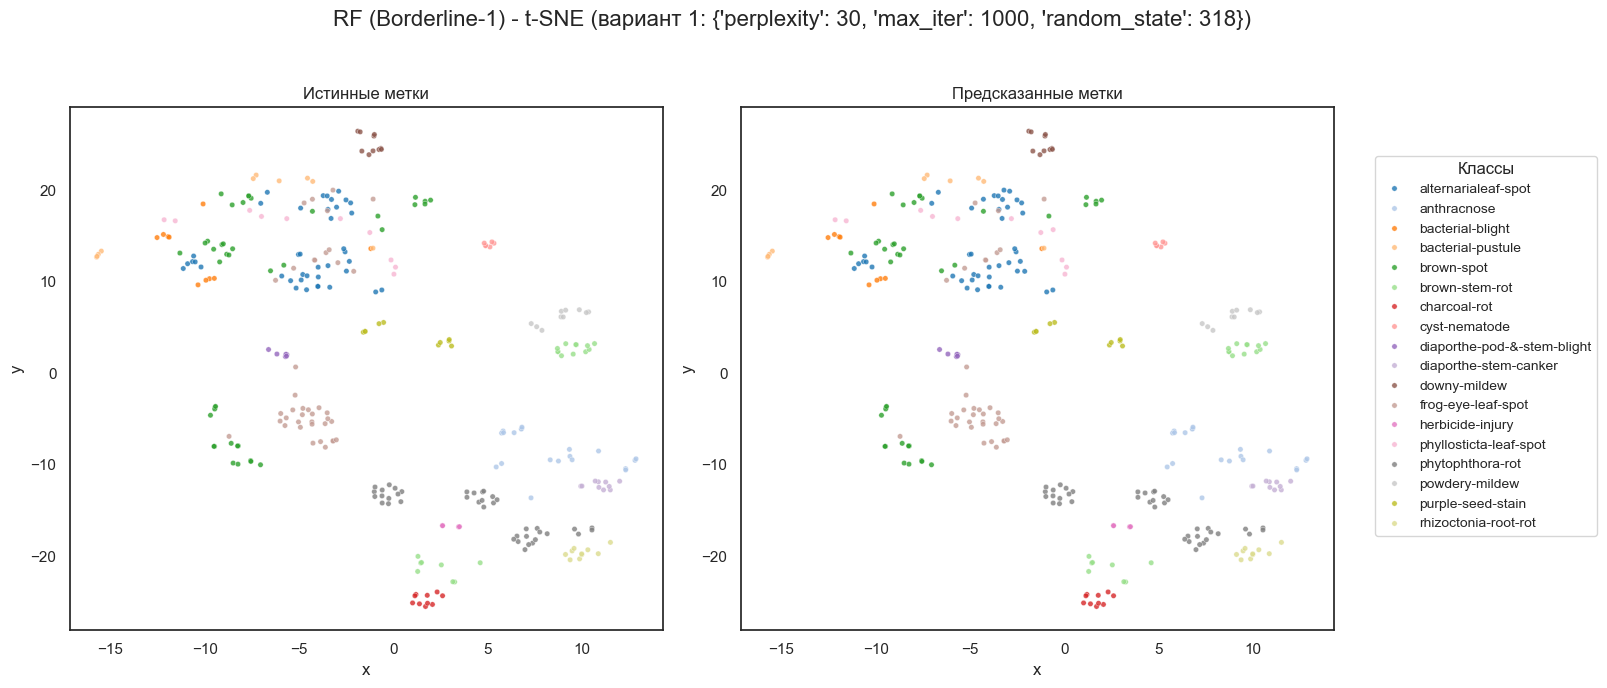

Выполняется t-SNE с параметрами: {'perplexity': 5, 'max_iter': 1000, 'random_state': 318}...


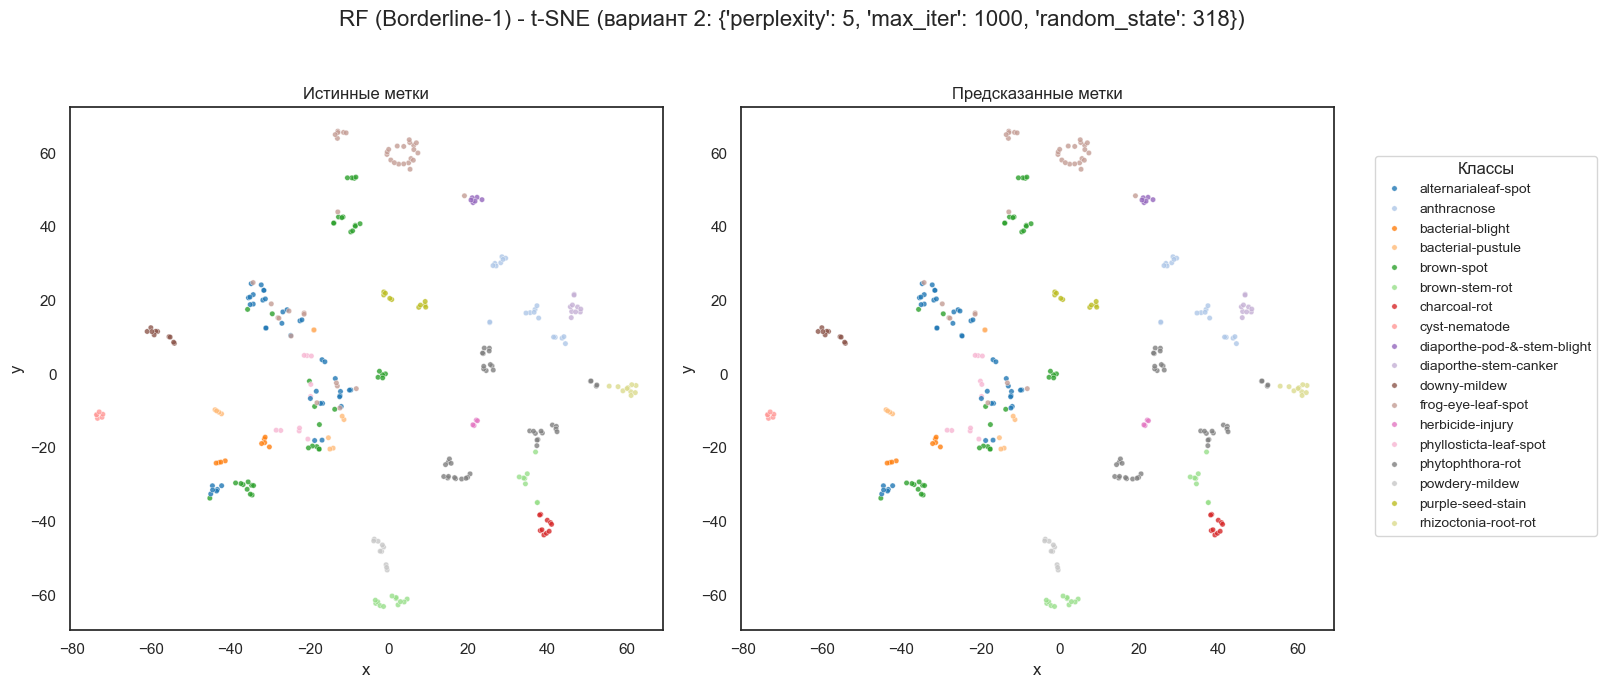

Выполняется UMAP с параметрами: {'n_neighbors': 15, 'min_dist': 0.1, 'random_state': 318}...


C:\Users\ursus\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


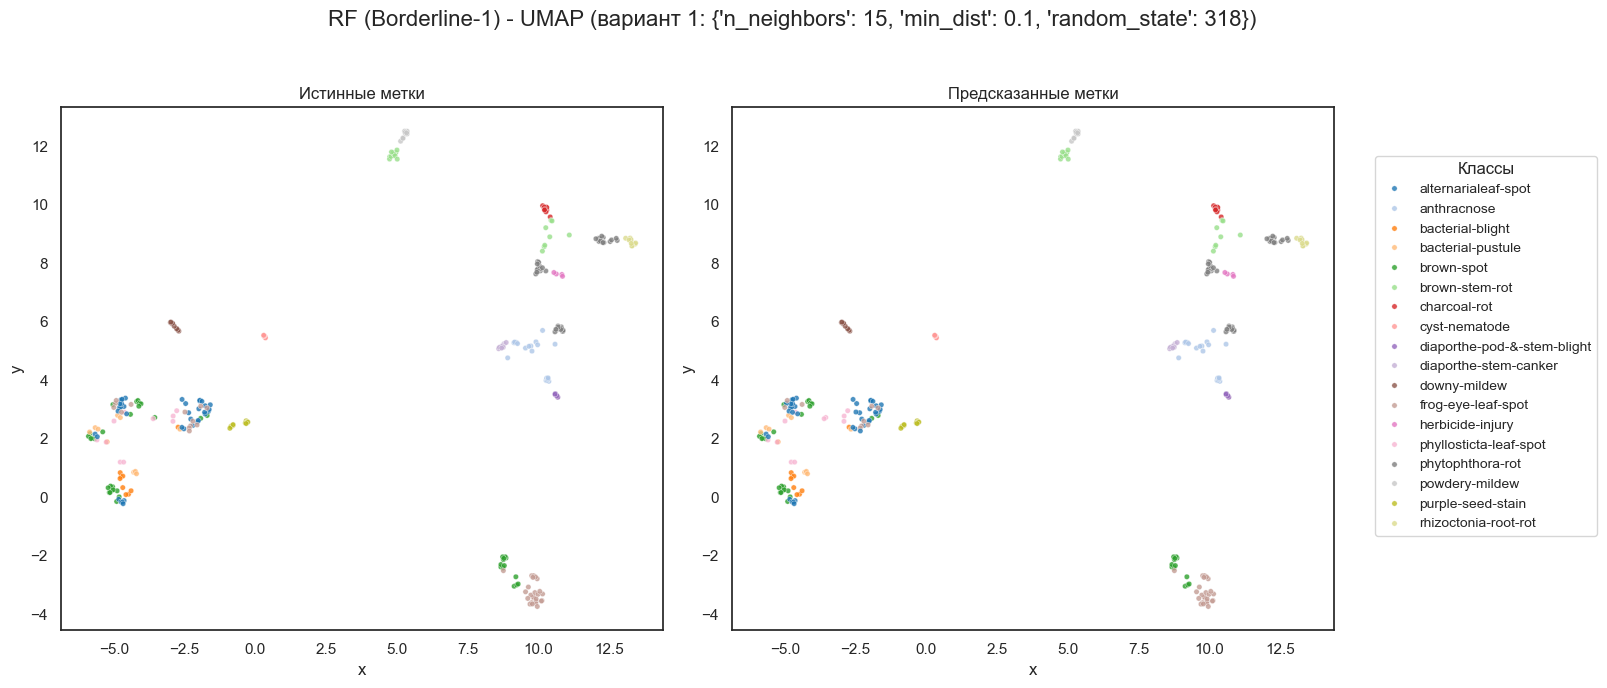

Выполняется UMAP с параметрами: {'n_neighbors': 5, 'min_dist': 0.1, 'random_state': 318}...


C:\Users\ursus\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


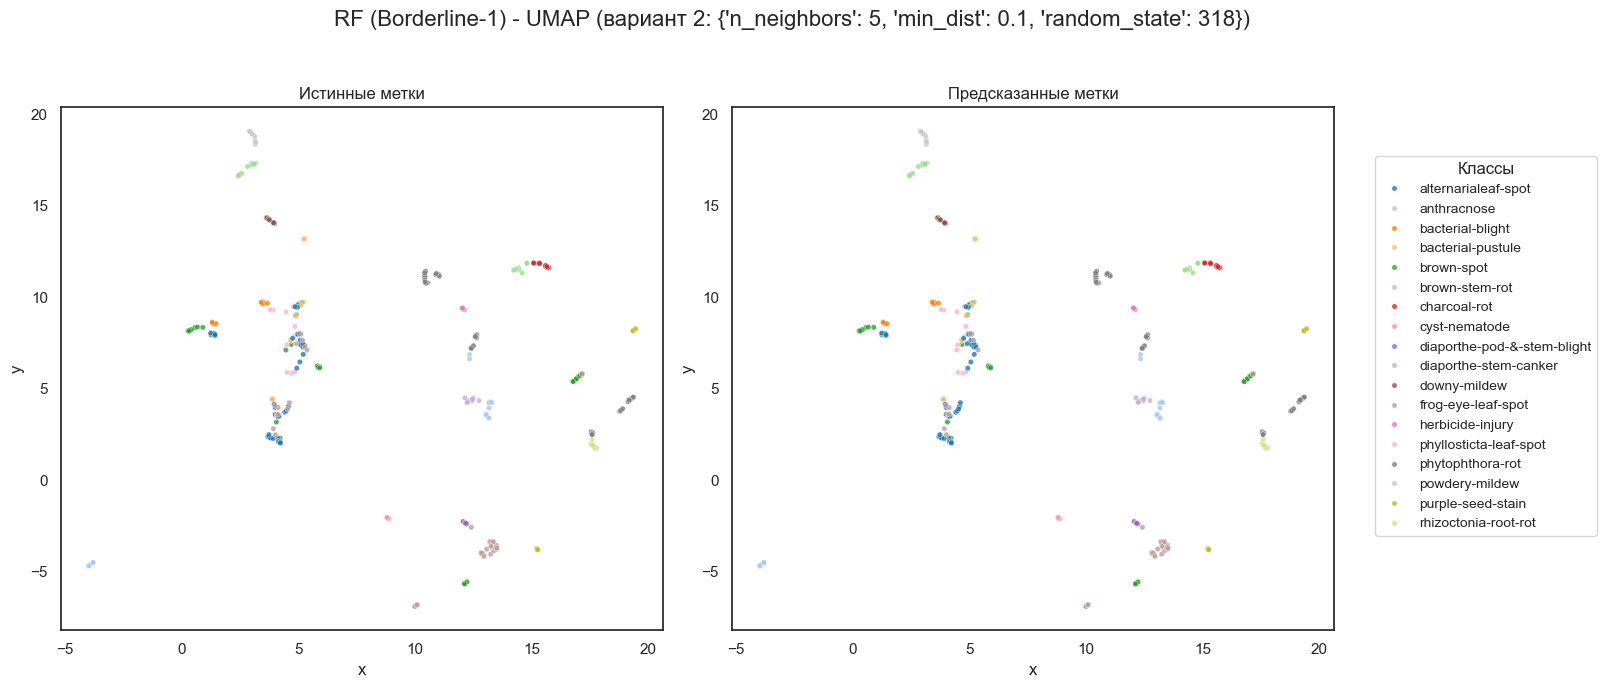

Выполняется TriMAP с параметрами: {'n_dims': 2, 'n_random': 318}...


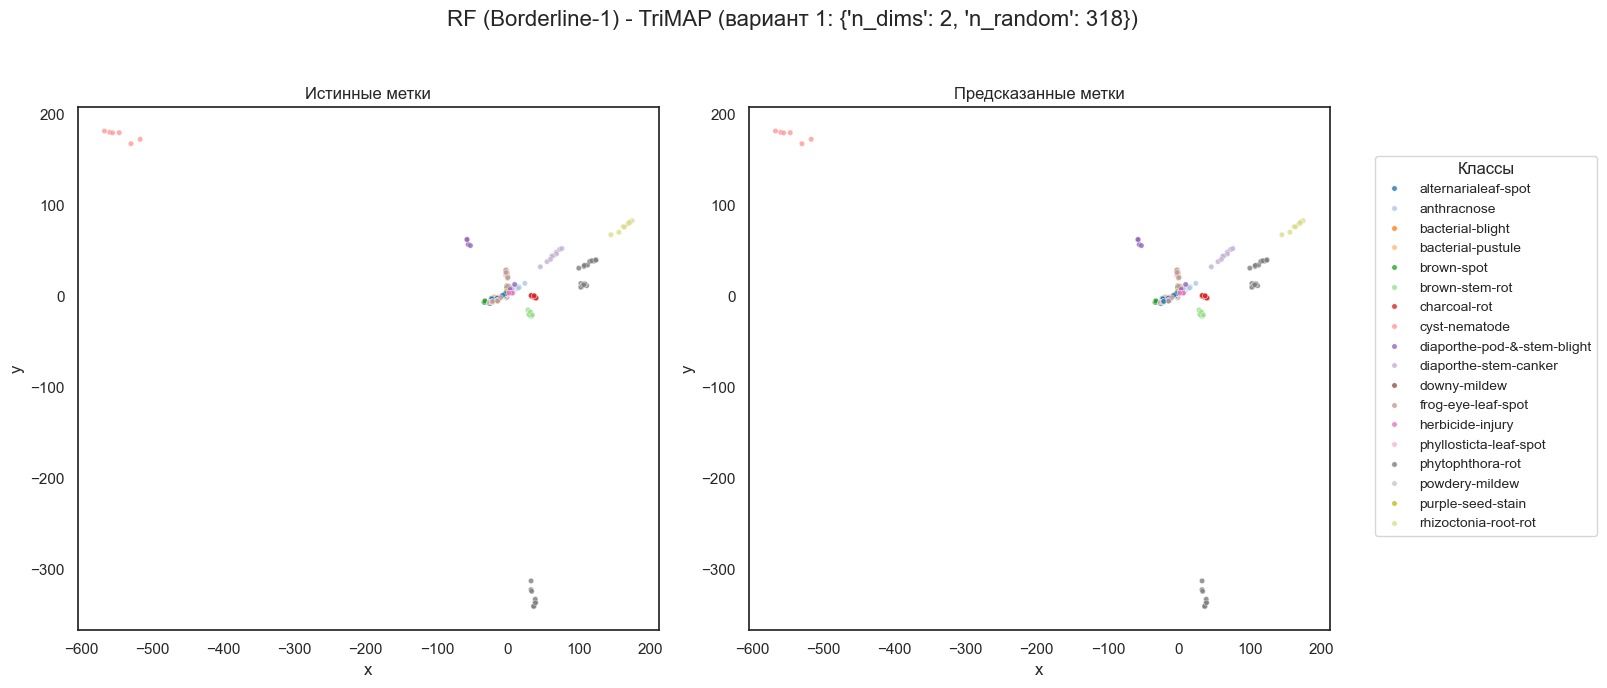

Выполняется TriMAP с параметрами: {'n_dims': 2, 'n_inliers': 5, 'n_random': 318}...


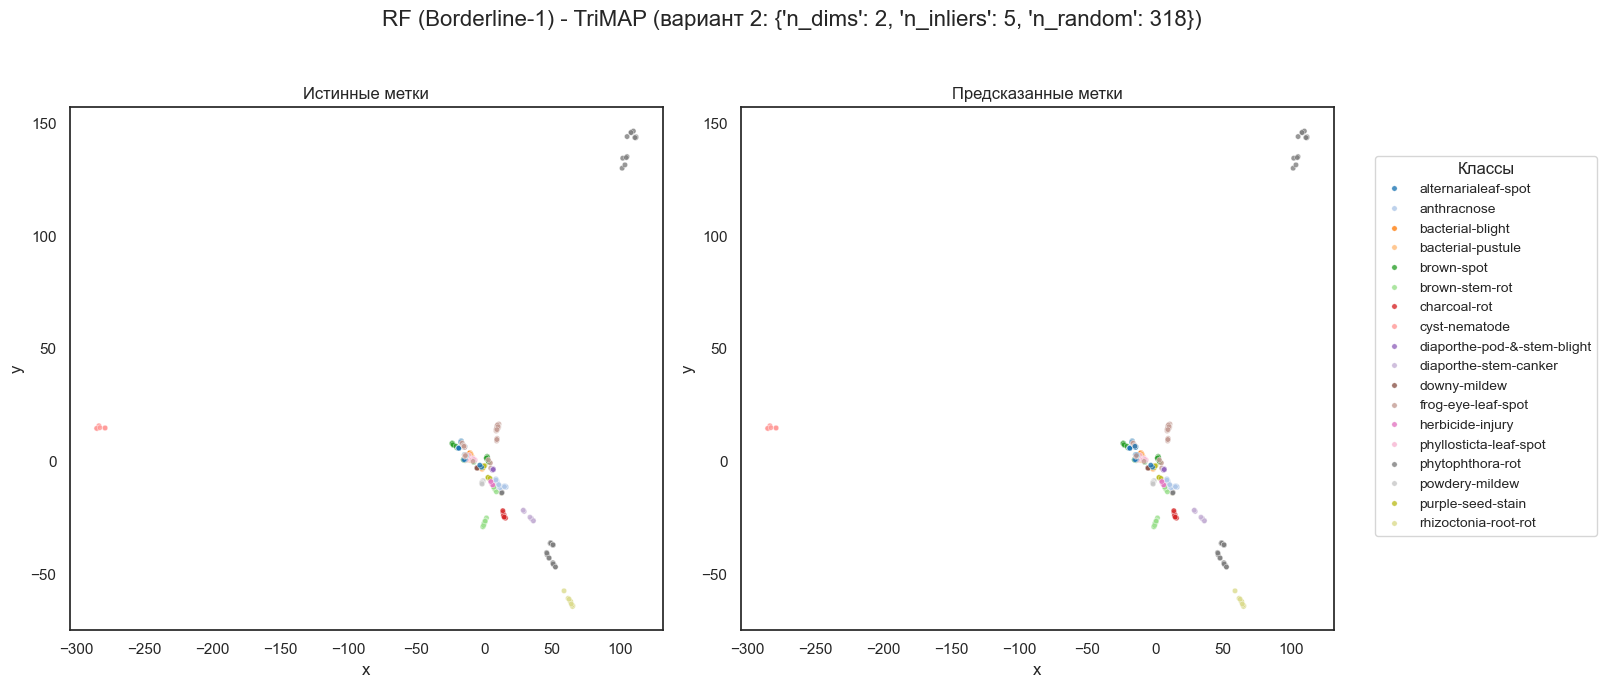

Выполняется PaCMAP с параметрами: {'n_components': 2, 'n_neighbors': 10, 'random_state': 318}...


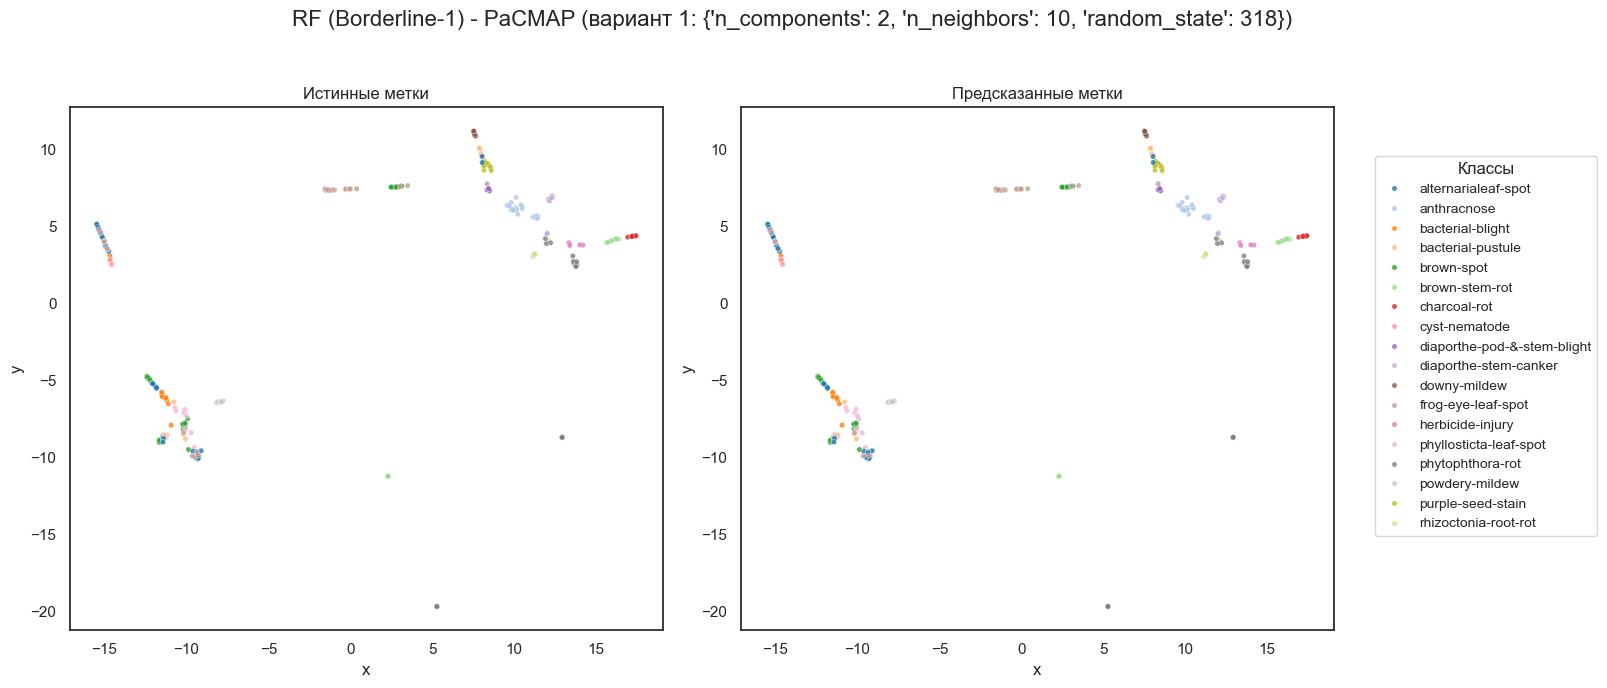

Выполняется PaCMAP с параметрами: {'n_components': 2, 'n_neighbors': 5, 'random_state': 318}...


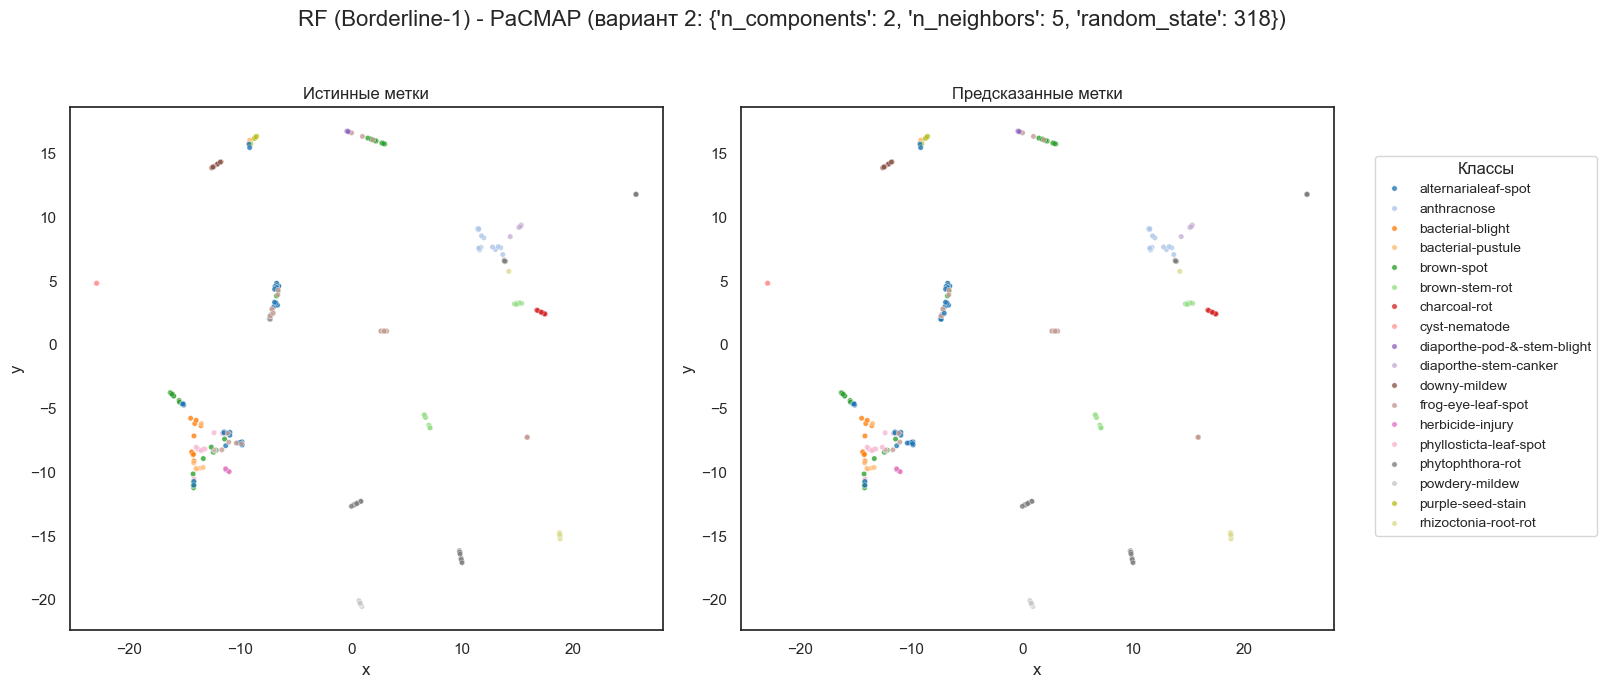

In [524]:
filtered_results_df = results_df.copy()

best_model_name = filtered_results_df.index[0]
best_model_score = filtered_results_df.iloc[0]['Weighted F1-Score']

if 'RF' in best_model_name:
    final_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
elif 'SVM' in best_model_name:
    final_model = SVC(kernel='rbf', random_state=42)
elif 'k-NN' in best_model_name:
    final_model = KNeighborsClassifier(n_neighbors=5)
else:
    raise ValueError(f"Неизвестный тип модели в названии: {best_model_name}")

if 'SMOTE' in best_model_name:
    X_train_best, y_train_best = balanced_datasets["SMOTE"]
elif 'Borderline-1' in best_model_name:
    X_train_best, y_train_best = balanced_datasets["Borderline-1"]
elif 'Borderline-2' in best_model_name:
    X_train_best, y_train_best = balanced_datasets["Borderline-2"]
elif 'Baseline' in best_model_name:
    X_train_best, y_train_best = X_train_scaled, y_train
else:
    raise ValueError(f"Неизвестный тип данных в названии: {best_model_name}")

final_model.fit(X_train_best, y_train_best)
X_full_scaled = scaler.transform(X_imputed)
plot_embeddings_comparison(
    X_data=X_full_scaled,
    y_true=y_encoded,
    model=final_model,
    label_encoder=le,
    title_prefix=f"{best_model_name}"
)